# 01 · Data quality & EDA
Project FORESIGHT · NorthBay Living. Explores the cleaned data produced by `src/pipeline.py`. Run `python run_pipeline.py` first (it writes the figures shown here).

In [1]:
import sys, json, warnings; warnings.filterwarnings('ignore')
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
import pandas as pd, numpy as np
from IPython.display import Image, display
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 20); pd.set_option('display.max_colwidth', 80)

## 1. Ingest and clean (the same code the pipeline runs)

In [2]:
from src import pipeline
d = pipeline.run(save=False)
daily, weekly, inv, master = d['daily'], d['weekly'], d['inventory'], d['master']
print(daily.shape, weekly.shape, inv.shape, master.shape)

[pipeline] daily rows=36,550  weekly rows=5,200  SKUs=50  weeks=104  DQ checks=23
(36550, 22) (5200, 9) (1200, 9) (50, 10)


## 2. Data-quality log
Every check the pipeline runs, including those that found nothing.

In [3]:
d['dq'][['table','check','rows_affected','action']]

,table,check,rows_affected,action
0,sku_master,Duplicate SKU rows,0,Kept last occurrence
1,sku_master,Unlabelled column 'wfr',50,Renamed to unit_cost (identity price - wfr = margin holds for 50/50 rows)
2,sku_master,Unit cost above selling price (negative margin),16,Kept as-is and flagged (negative_margin=True)
3,sku_master,Category/subcategory labels inconsistent,30,"Kept; category used as the grouping level, subcategory flagged as unreliable"
4,sales_daily,Unparseable dates,0,Dropped
5,sales_daily,Missing numeric values,0,units_sold missing -> row dropped; promo_flag missing -> 0; price missing ->...
6,sales_daily,"Duplicate (date, SKU) rows",0,Kept last occurrence
7,sales_daily,Negative units,0,Clipped to 0
8,sales_daily,Revenue != units x price,0,Recomputed revenue
9,sales_daily,SKUs not in sku_master,0,Dropped


## 3. Structure and grain

In [4]:
print('Dates:', daily.date.min().date(), '->', daily.date.max().date(), '|', daily.date.nunique(), 'days')
print('SKUs with sales:', daily.sku_id.nunique(), '| rows per SKU:', daily.groupby('sku_id').size().unique())
print('Inventory snapshots:', sorted(inv.date.dt.strftime('%Y-%m-%d').unique())[:3], '... monthly,', inv.date.nunique(), 'snapshots')
daily.describe().T[['mean','std','min','max']]

Dates: 2024-01-01 -> 2025-12-31 | 731 days
SKUs with sales: 50 | rows per SKU: [731]
Inventory snapshots: ['2024-01-01', '2024-02-01', '2024-03-01'] ... monthly, 24 snapshots


,mean,std,min,max
date,2024-12-31 00:00:00,NaN,2024-01-01 00:00:00,2025-12-31 00:00:00
units_sold,14.00301,8.467305,0.0,56.0
revenue,84707.43385,76534.63044,0.0,546977.0
unit_price,5892.6638,3138.775609,663.46,11642.45
promo_flag,0.102599,0.303439,0.0,1.0
is_weekend,0.284542,0.451202,0.0,1.0
is_holiday,0.010944,0.104041,0.0,1.0
is_promo_event,0.102599,0.303439,0.0,1.0
unit_cost,3770.7294,2005.453732,307.06,7748.2
list_price,5892.6638,3138.775609,663.46,11642.45


## 4. Demand distribution

In [5]:
wk = weekly.groupby('sku_id').units.agg(['mean','std']); wk['cv'] = wk['std']/wk['mean']
wk.describe().round(2)

,mean,std,cv
count,50.00,50.00,50.00
mean,98.09,16.11,0.18
std,50.07,6.75,0.03
min,18.73,4.79,0.14
25%,59.33,10.47,0.16
50%,99.03,16.11,0.17
75%,138.79,22.55,0.19
max,182.65,29.77,0.26


## 5. Trend and seasonality

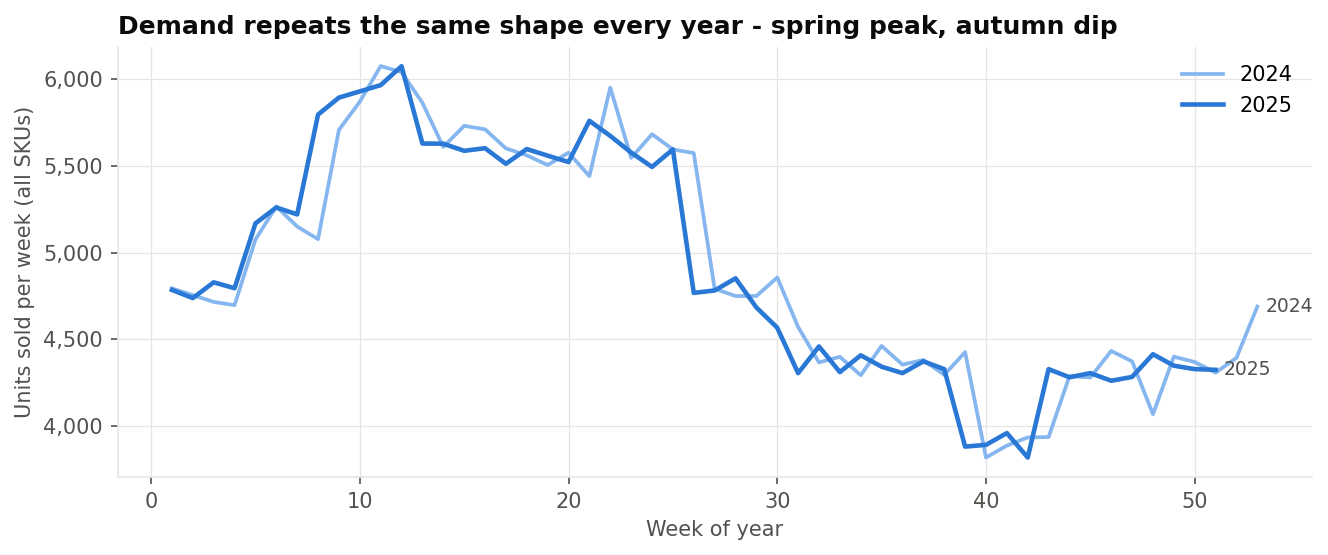

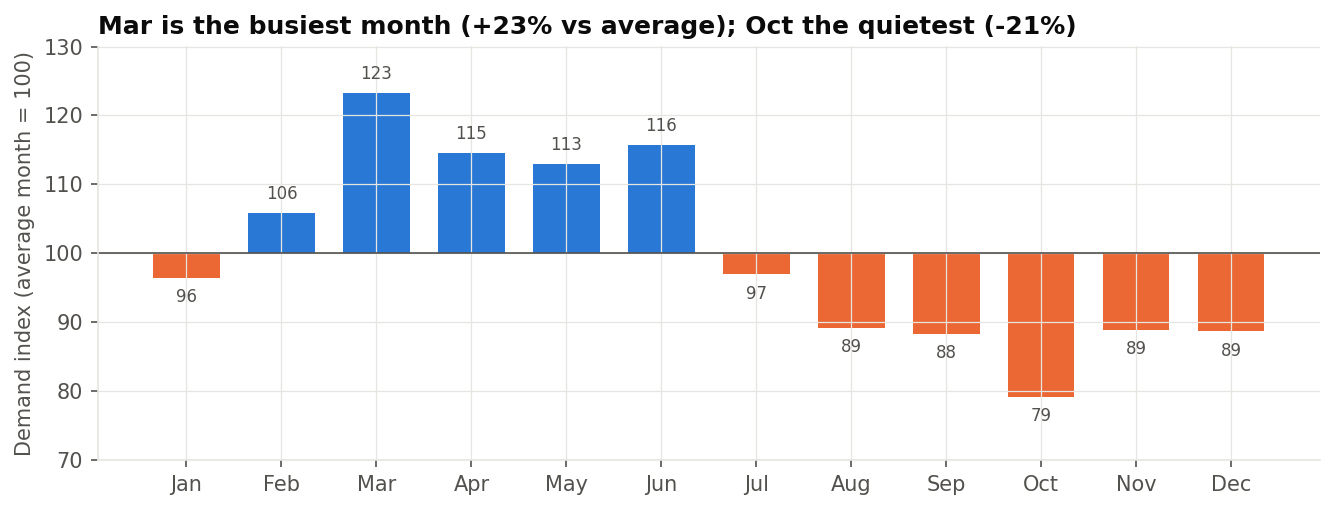

In [6]:
display(Image(str(ROOT/'reports/figures/01_weekly_demand_by_year.png')))
display(Image(str(ROOT/'reports/figures/02_monthly_seasonality.png')))

In [7]:
tot = weekly.groupby('week_start').units.sum()
print('Year-on-year change in average weekly units: %.2f%%' % (100*(tot[tot.index.year==2025].mean()/tot[tot.index.year==2024].mean()-1)))
print('Correlation of weekly totals with the same week a year earlier: %.3f' % np.corrcoef(tot.values[52:], tot.values[:52])[0,1])

Year-on-year change in average weekly units: -0.06%
Correlation of weekly totals with the same week a year earlier: 0.988


## 6. Drivers: weekend, promotion, holidays, category

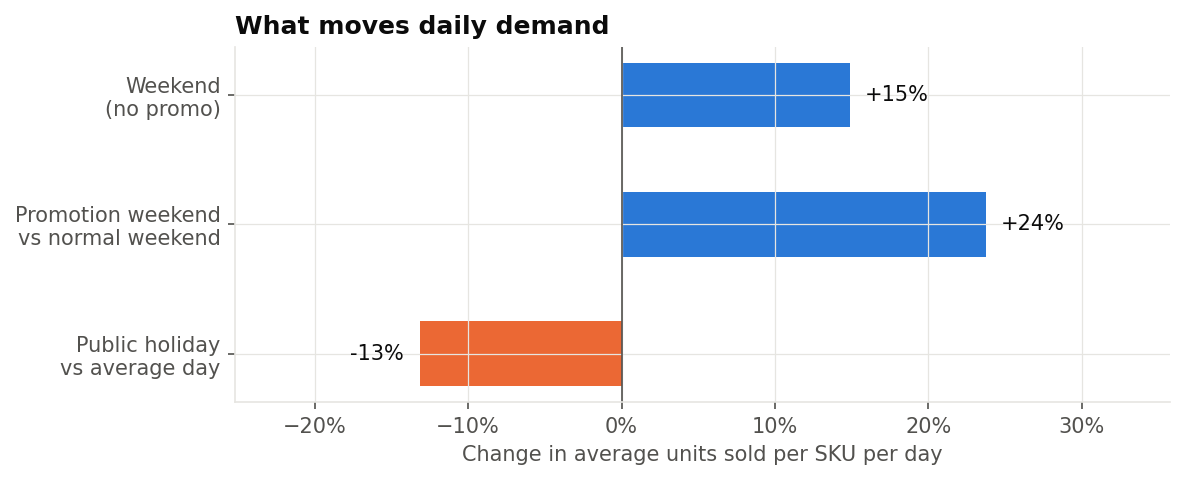

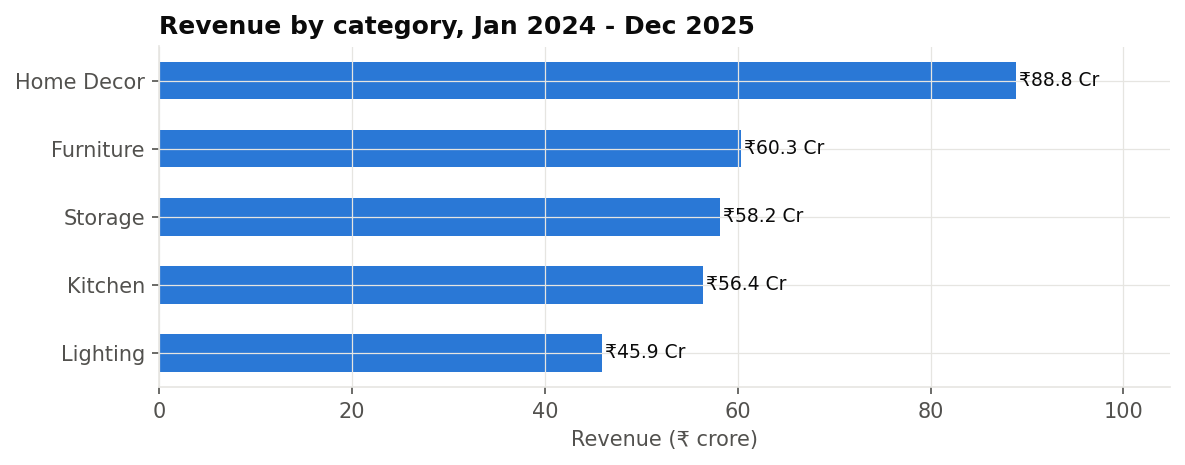

season
Autumn     11.77
Monsoon    12.83
Winter     13.56
Summer     16.01
Spring     16.67
Name: units_sold, dtype: float64

In [8]:
display(Image(str(ROOT/'reports/figures/03_demand_drivers.png')))
display(Image(str(ROOT/'reports/figures/04_category_revenue.png')))
daily.groupby('season').units_sold.mean().round(2).sort_values()

## 7. Top movers, best-sellers and dead / slow stock

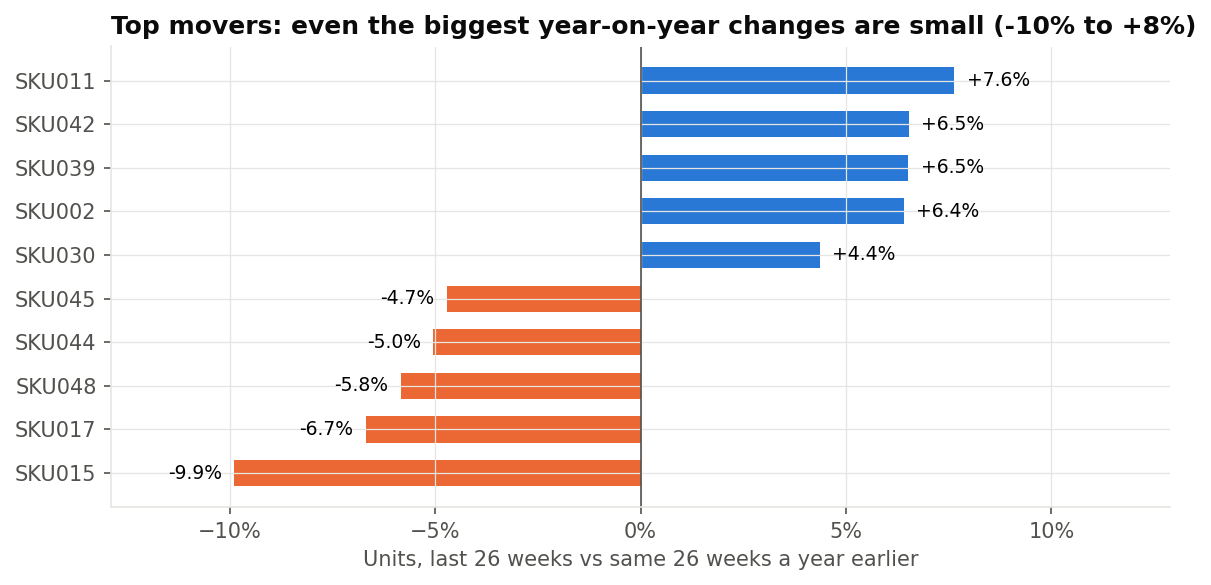

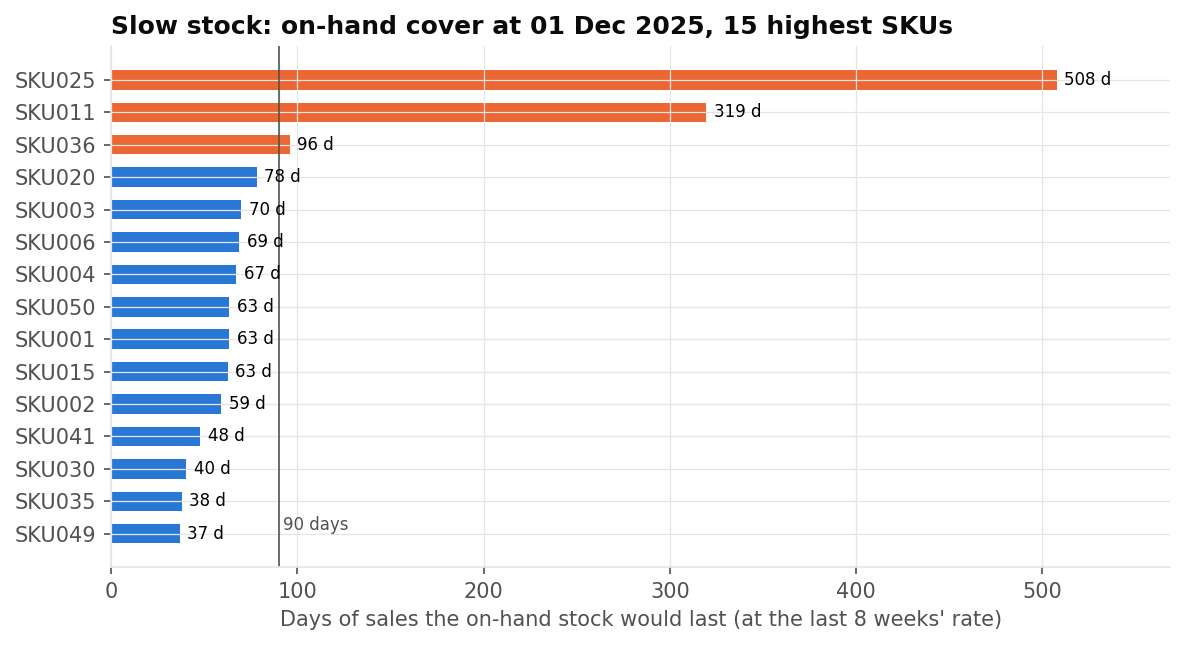

In [9]:
display(Image(str(ROOT/'reports/figures/05_top_movers_yoy.png')))
display(Image(str(ROOT/'reports/figures/06_days_of_cover.png')))

In [10]:
E = json.loads((ROOT/'outputs/eda_summary.json').read_text())
{k: E[k] for k in ['top10_revenue_share_pct','skus_for_80pct_revenue','slow_stock_skus_over_90d','slow_stock_value_inr','orphan_skus','orphan_units_on_hand','negative_margin_skus','negative_margin_revenue_share_pct','price_volume_corr','stock_rollforward_within_20pct_share','stock_change_vs_sales_corr']}

{'top10_revenue_share_pct': 47.7,
 'skus_for_80pct_revenue': 24,
 'slow_stock_skus_over_90d': {'SKU025': 508, 'SKU011': 319, 'SKU036': 96},
 'slow_stock_value_inr': 4872073.08,
 'orphan_skus': 150,
 'orphan_units_on_hand': 39985,
 'negative_margin_skus': 16,
 'negative_margin_revenue_share_pct': 16.7,
 'price_volume_corr': 0.099,
 'stock_rollforward_within_20pct_share': 0.091,
 'stock_change_vs_sales_corr': -0.013}

## 8. Correlations across SKUs

In [11]:
sku = daily.groupby('sku_id').agg(price=('unit_price','first'), cost=('unit_cost','first'), margin=('gross_margin_per_unit','first'), units_per_day=('units_sold','mean'))
sku.corr().round(2)

,price,cost,margin,units_per_day
price,1.00,-0.01,0.84,0.10
cost,-0.01,1.00,-0.55,-0.11
margin,0.84,-0.55,1.00,0.14
units_per_day,0.10,-0.11,0.14,1.00


## Findings (carried into `reports/EDA_Insight_Memo.pdf`)
1. Demand is seasonal and stable: the same spring peak / autumn dip both years, near-zero growth. Same-week-last-year is a strong starting point, which is why it is the baseline to beat.
2. Weekends, promotions (weekends of Mar/Jun/Sep/Nov) and holidays move demand predictably - features worth giving the model.
3. Stock is badly mismatched to demand: a handful of SKUs have days of cover left while others hold over a year.
4. Data issues need client confirmation: 150 stock-only SKUs, 16 SKUs priced below cost, unreliable launch dates and subcategories, stock snapshots that do not reconcile.